In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv")

In [3]:
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [4]:
df = df.dropna(subset=["Age", "Fare", "Embarked"])

In [5]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipykernel_17/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [6]:
# Cabin -> too many missing values, we drop this column
df.drop(columns=["Cabin"], inplace=True)

In [7]:
# Embarked -> fill with mode (most common value)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


/tmp/ipykernel_17/3248514066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [8]:
# 2. Encode Categorical Variables
# -----------------------------
# Encode 'Sex' (male/female) and 'Embarked' (C, Q, S)
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])   # male=1, female=0
df["Embarked"] = le.fit_transform(df["Embarked"])


In [9]:
# 3. Feature Scaling
# -----------------------------
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])


In [10]:
# 3. Feature Scaling
# -----------------------------
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])


In [11]:
# Final Dataset
# -----------------------------
print("Processed Data Sample:\n")
print(df.head())

Processed Data Sample:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.527669      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.577094      1   
2                             Heikkinen, Miss. Laina    0 -0.251478      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.369951      1   
4                           Allen, Mr. William Henry    1  0.369951      0   

   Parch            Ticket      Fare  Embarked  
0      0         A/5 21171 -0.516380         2  
1      0          PC 17599  0.694046         0  
2      0  STON/O2. 3101282 -0.503620         2  
3      0            113803  0.350326         2  
4      0            373450 -0.501257         

In [12]:
print("\nMissing values left in dataset:")
print(df.isnull().sum())


Missing values left in dataset:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


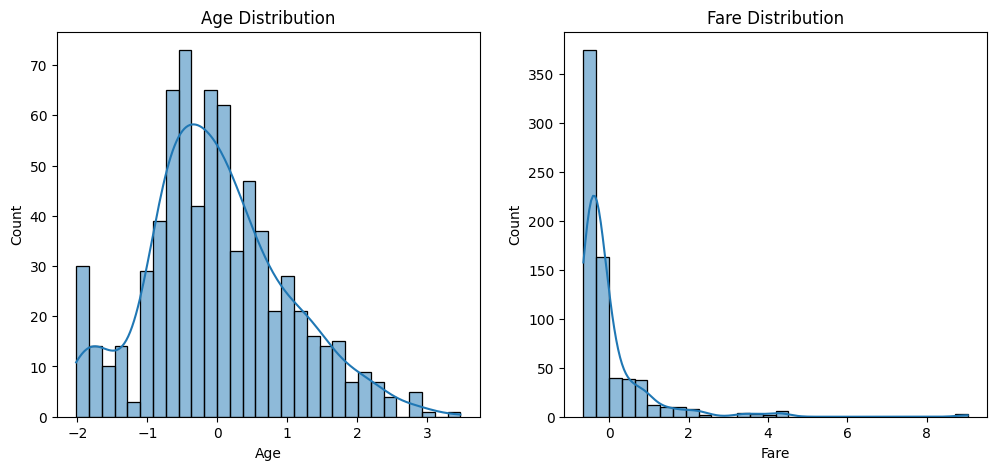

In [13]:
# --------- Histograms ---------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["Fare"], bins=30, kde=True)
plt.title("Fare Distribution")

plt.show()

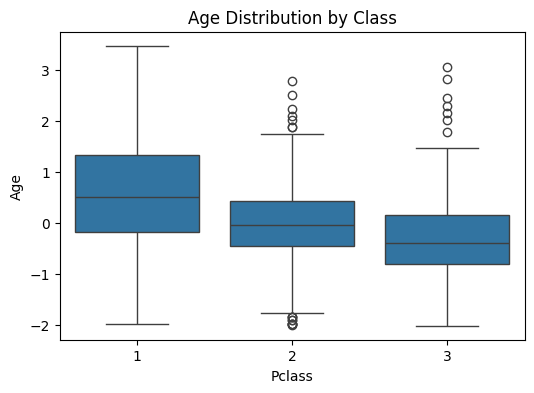

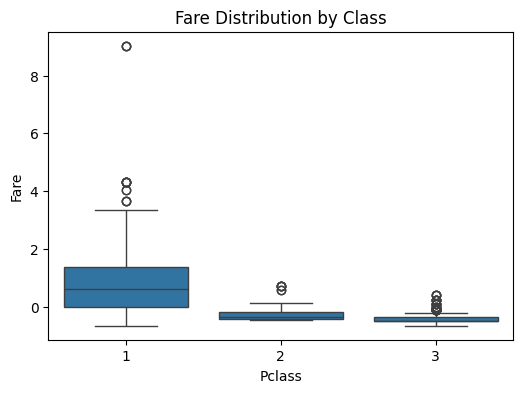

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Pclass", y="Age")
plt.title("Age Distribution by Class")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare Distribution by Class")
plt.show()

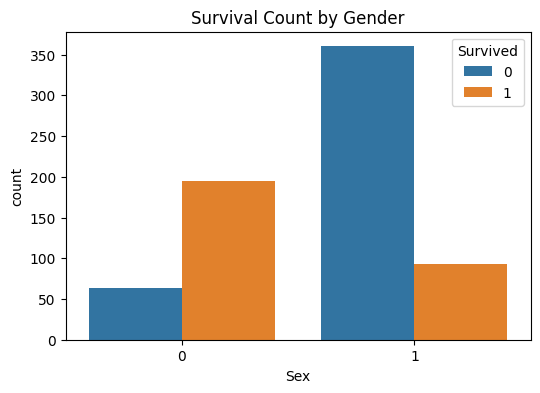

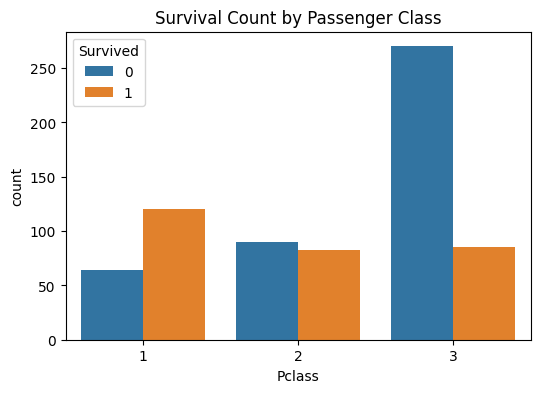

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival Count by Gender")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival Count by Passenger Class")
plt.show()
